# Otimizadores

Autor(a): Aline Silva dos Santos.

### Introdução:

Imagine um estudante cursando um bacharelado interdisciplinar em Ciência e Tecnologia que precisa lidar com diversos fatores em sua rotina, como aulas, pesquisas, trabalhos, atividade física, sono, refeições e tempo de descanso, buscando organizá-los da maneira mais eficiente possível. Esse estudante está, na prática, diante de um problema de otimização, porque seu objetivo é minimizar o tempo desperdiçado e o estresse, ao mesmo tempo em que maximiza a eficiência nos estudos, a qualidade do sono e o tempo disponível para atividades acadêmicas. Nesse sentido, podemos pensar a rotina como uma função que precisa ser equilibrada da forma mais adequada possível. Na matemática e na vida cotidiana, otimização significa buscar o melhor valor de uma função. Em `deep learning`, ocorre de forma semelhante, mas, em vez de otimizar uma rotina, otimizamos uma função de perda para que o modelo faça previsões melhores, pois, nesse caso, o valor ótimo é o ponto em que a perda é mínima, ou seja, quando o modelo erra menos nas previsões.

Desse modo, para transformar problemas reais em algo menos abstrato e traduzi-los para uma linguagem funcional e resolvível, é necessário contarmos com ferramentas matemáticas e computacionais. Dois conceitos fundamentais na área de otimização são minimização e maximização, pois é exatamente isso que se busca ao resolver um problema de otimização. Para compreendê-los melhor, é importante recorrer aos conceitos de derivada, gradiente e ideias correlatas. Nas aulas de cálculo, somos apresentados a esses conceitos e aprendemos que, ao igualarmos a derivada a zero, encontramos pontos críticos que podem corresponder a máximos ou mínimos de uma função. Essa ideia se estende, de forma mais elaborada, ao `deep learning`.

Para quem entende minimamente o funcionamento de uma rede neural, sabe que ela é regida por diferentes parâmetros, tais como pesos e vieses, e é mediante a atualização desses fatores que se torna possível reduzir a função de perda envolvida na rede, a qual permeia a qualidade de aprendizado da rede, pois, quanto menor a função de perda, mais assertiva a rede se torna com relação às suas previsões, como já mencionado. Ou seja, o treinamento supervisionado consiste em ajustar iterativamente os parâmetros do modelo, guiado pelo gradiente da função de perda, de modo a reduzir o erro de predição e melhorar a generalização. De maneira simplificada, os otimizadores de redes neurais determinam como cada parâmetro deve ser alterado a cada iteração de treinamento e também avaliam a distância entre os valores reais e as previsões das redes. Um traço importante é que eles são programados para reduzir esse erro progressivamente [1][2].


### 1. Fundamentos 

Inicialmente, convém apresentar alguns conceitos bases que irão permear essa jornada para se compreender adequadamente o funcionamento dos otimizadores, suas funções e tipos. Para isso, abaixo estão listados alguns tópicos fundamentais que são pré-requisito para seguirmos.

* Função de perda

É uma fórmula capaz de quantificar a performance do modelo, uma métrica numérica, que mede o quanto as previsões de um modelo se afastam dos valores reais. Ela se concentra na distância entre os valores, não na direção. Ela mede o desempenho do modelo em cada exemplo ou em um conjunto de dados, permitindo comparar diferentes configurações e orientar o ajuste dos parâmetros. Em problemas de regressão, exemplos comuns são o erro quadrático médio (MSE) e o erro absoluto médio (MAE), em classificação, são muito usadas a entropia cruzada binária (BCE) e a entropia cruzada categórica (CCE). Logo, quanto menor o valor dessa função, melhor tende a ser o desempenho do modelo. No treinamento de redes neurais, o algoritmo tenta minimizar essa perda ajustando pesos e vieses passo a passo. Por isso, a função de perda é central em `deep learning`, pois, além de medir o erro, ela também auxilia guiando o processo de aprendizagem.
  
* Gradiente

Representado por $\nabla f$, o gradiante de uma função $f$ é um vetor formado por todas as suas derivadas parciais, reunindo em uma única expressão como se da variação de $f$ em relação a cada uma de suas variáveis. Quando avaliado em um ponto $(x_0, y_0)$, esse vetor aponta na direção de crescimento mais rápido da função (a subida mais íngreme). De modo geral, para um ponto $(x, y)$, o gradiente é dado por:$$\nabla f = \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)$$

  
* Taxa de aprendizado

Geralmente denotada por $\eta$ trata-se do tamanho do passo que o modelo dá ao ajustar seus parâmetros durante o treinamento de um modelo. Conceitualmente, ela determina quão rapidamente o modelo aprende a partir dos erros, valores altos podem causar instabilidade e impedir a convergência, enquanto valores baixos tornam o aprendizado lento. Matematicamente, ela aparece na regra do gradiente descendente, o algoritmo de otimização mais fundamental em `deep learning` e serve como base para a maioria das outras técnicas avançadas. A escolha dessa taxa é crítica devido ao grande número de parâmetros, influenciando diretamente a eficiência e a estabilidade do treinamento, sendo frequentemente ajustada dinamicamente por técnicas como decaimento, *warm-up* ou por otimizadores adaptativos como Adam. 

* Curva de aprendizado

Normalmente, durante o treinamento e aprendizagem dos modelos, se faz necessário ferramentas que viabilizem o acompanhamento de como os erros ou acertos variam nas diferentes etapas do processo. Nesse sentido, surge a chamada curva de aprendizado, uma representação gráfica do comportamento do modelo ao longo do treinamento, permitindo observar como a perda/acurácia evoluem em função das épocas (ciclo completo de treinamento). Em geral, essa curva é analisada tanto no conjunto de treino quanto no de validação, o que possibilita compreender se o modelo está realmente aprendendo padrões úteis ou apenas se ajustando excessivamente aos dados de treinamento (overfitting). Desse modo, sua importância está justamente no fato de que ela funciona como um auxílio na identificação de situações como underfitting, quando o modelo ainda não aprendeu padrões relevantes, e overfitting, perdendo, então, a capacidade de generalização. Dessa forma, tê- la em mente não apenas ajuda a evidenciar o comportamento do modelo durante o treinamento, mas também orienta decisões sobre ajustes de hiperparâmetros, tempo de treinamento e escolha do otimizador. Por isso, esse conceito é essencial para prosseguirmos com o estudo relativo aos otimizadores. Abaixo são apresentados exemplos de curvas de perda e acurácia bem comportadas [9]:

<div style="text-align: center;">
    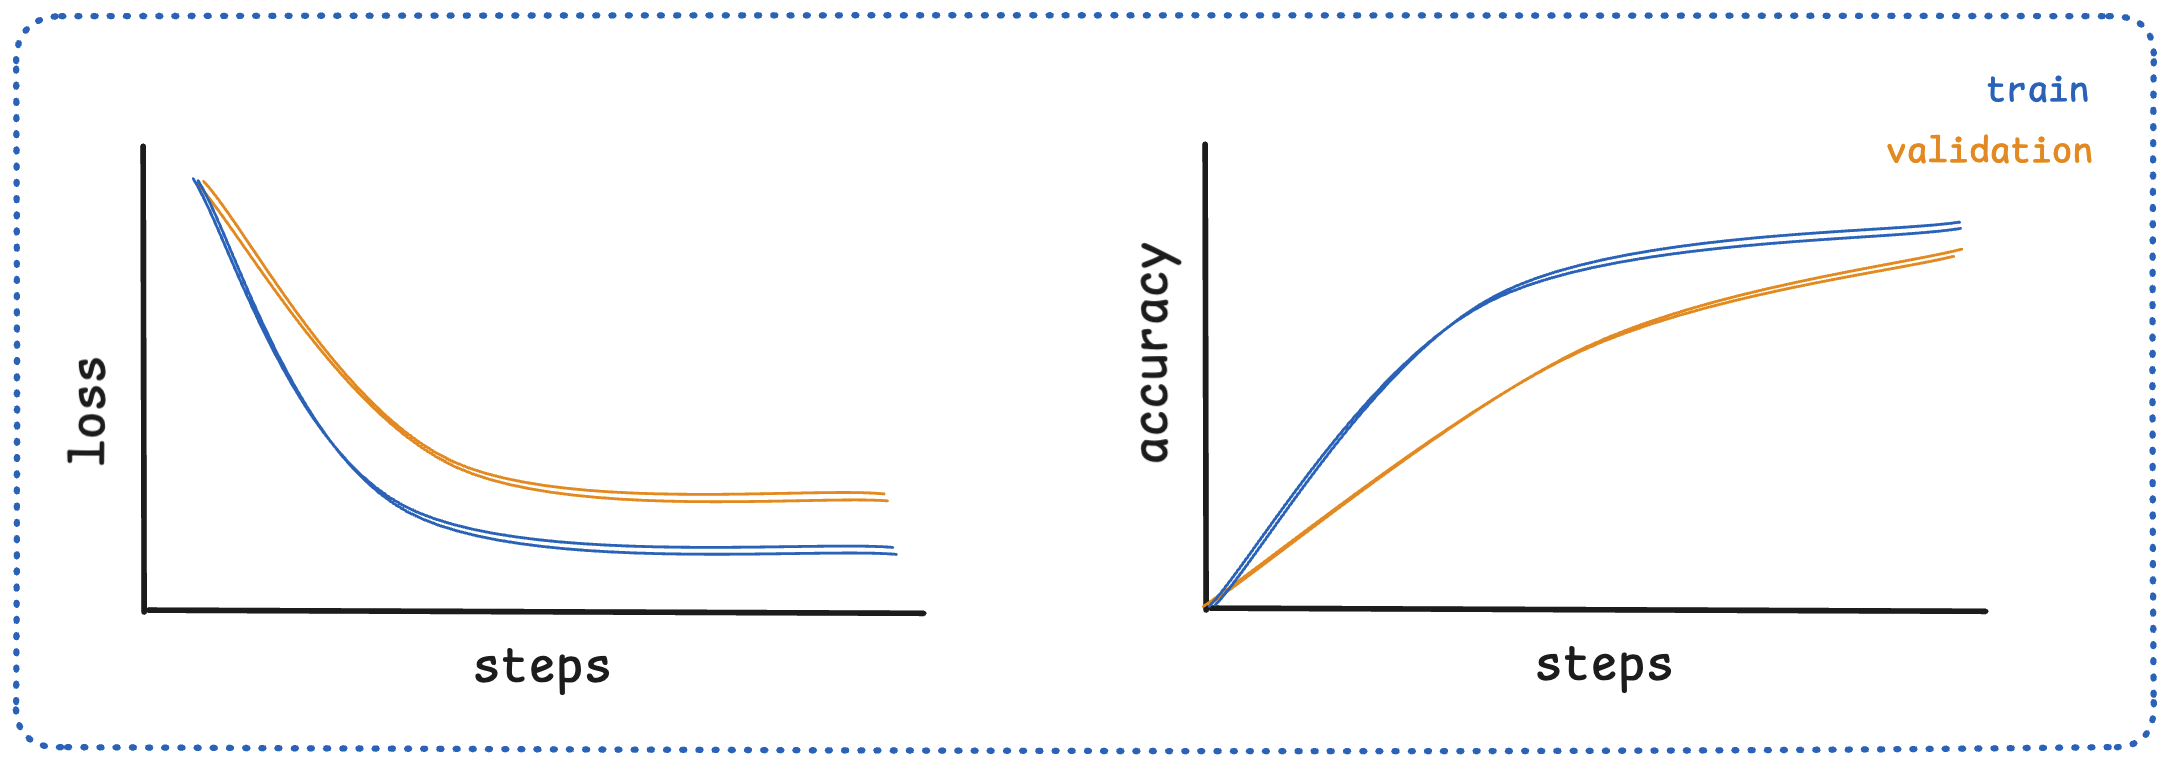
</div>

Percebe-se, pelos gráficos acima, que características comuns à curvas boas englobam:

* Declínio suave, ou seja, devem diminuir de forma constante;
* Desempenho próximo entre treinamento e validação;
* Convergência, as curvas devem se estabilizar indicando que o modelo aprendeu os padrões.


Com esses conceitos bem fundamentos é possível reforçar a ideia já introduzida da importância dos otimizadores. Em uma rede neural, os parâmetros do modelo, como pesos e vieses, são os valores internos que serão ajustados durante o treinamento. O objetivo, portanto, é atingir o ponto ótimo referente a maior redução de erro das predições do modelo, ou seja, encontrar a configuração que minimize a função de perda, esse valor representa o menor erro possível entre as previsões do modelo e os valores reais. Nessa tarefa, o trabalho dos otimizadores é essencial e por meio deles que conseguimos alcançar melhores níveis de aproximação.

### 2. Gradient Descent, Stochastic Gradient Descent e  Momentum 

Nesta etapa vamos começar a apresentar os otimizadores existentes com base nos princípios já revelados até aqui. 

* Gradient Descent (GD)-  algoritmo que funciona calculando o gradiente da função de perda em relação a cada parâmetro na rede. Em seguida, atualiza esses parâmetros na direção oposta ao gradiente da função de custo, sua regra de atualização se dá da seguinte forma: $$\theta_{t+1} = \theta_t - \eta \nabla J(\theta_t) $$ Essa atualização ocorre de maneira iterativa, calculando o gradiente e atualizando os parâmetros, na esperança de convergir para um conjunto de parâmetros $\theta$ que resulte em um valor baixo para a função de perda.

<div style="text-align: center;">
    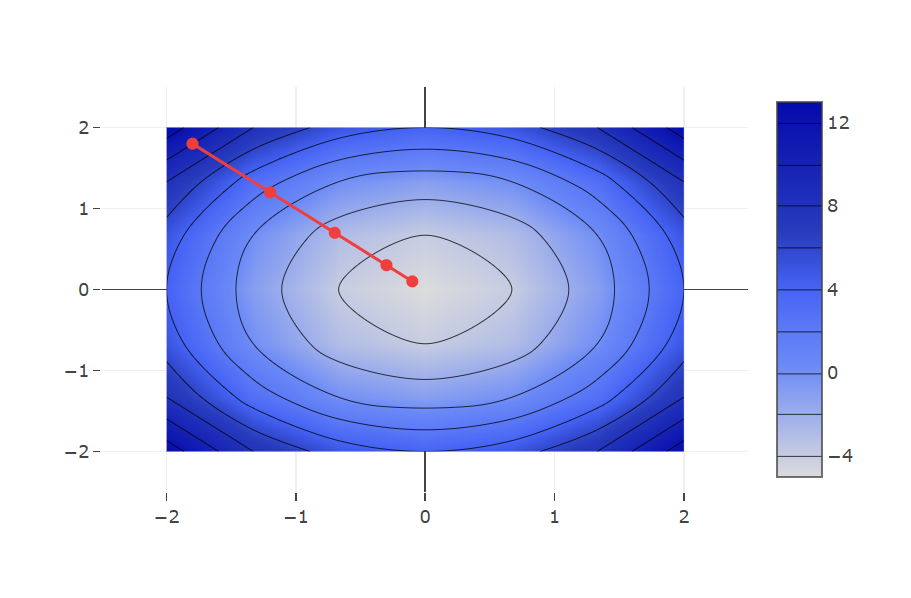
</div>


Acima temos uma representação gráfica da descida do gradiente, a descida ocorre percorrendo-se as curva de níveis até atingir o ponto mínimo da função. Uma superfície de perda 2D simplificada é exibida (os contornos representam valores de perda iguais). A linha vermelha mostra o caminho seguido pelo Gradiente Descendente, começando a partir de um ponto inicial e dando passos opostos ao gradiente em direção ao mínimo (área azul mais escura). [7]

Dentre os benefícios desse algoritmo temos o seu fácil entendimento conceitual e implementação, convegência garantida para problemas de otimização convexa (problemas que possuem um mínimo global fácil de encontrar) e boa estabilidade, inerente ao uso de todo o conjunto de dados. No entando, algumas desvantagens também estão atreladas a esse processo, pois é um algoritmo que não costuma lidar bem com problemas onde existem muitos mínimos locais (problemas não convexos), podendo gerar alto consumo de memória e lentidão para convergir, devido ao fato de processar todo o conjunto de dados. Além disso, possui uma taxa de aprendizagem fixa para todos os parâmetros.

Dessa forma, outras formulações ganham espaço para proporcionar melhores maneiras de otimização a depender do problema posto e suas especificidades.

* Stochastic Gradient Descent (SGD)- o gradiente estocástico busca resolver os problemas de convergência lenta do gradiente padrão, fazendo atualizações de parâmetros com mais frequência.  Isso significa que, em vez de calcular o gradiente usando todo o conjunto de dados, o algoritmo utiliza apenas um exemplo de treino por vez. Essa mundança colabora para reduzir o consumo de memória e acelerar a convergência. Outro ponto interessante é que, por conta da aleatoriedade das atualizações, o algoritmo pode ter mais facilidade para escapar de mínimos locais rasos. No entanto, essa mesma aleatoriedade também traz desvantagens notórias. Como o gradiente é calculado com base em apenas uma amostra, as atualizações podem apresentar alta variância, fazendo com que a função de perda oscile bastante ao longo do treinamento. Isso pode gerar um caminho mais instável e até levar a `overshooting`, isto é, quando o algoritmo ultrapassa o ponto ótimo em vez de se aproximar dele de forma suave. A representação gráfcica do SGD segue na imagem abaixo [3]:

<div style="text-align: center;">
    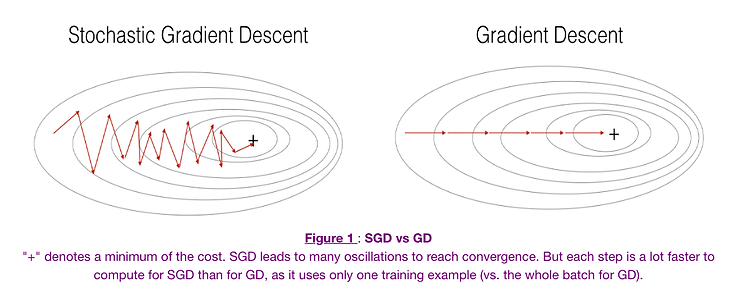
</div>

Por esse motivo, o SGD costuma exigir um ajuste cuidadoso da taxa de aprendizado pra conseguir convergir adequadamente. Assim, embora seja mais rápido e eficiente em termos computacionais, o SGD também é mais sensível ao comportamento do treinamento e pode demandar mais cuidado na escolha dos hiperparâmetros.
A regra de atualização do SGD obedece a seguinte fórmula:$$\theta_{t+1} = \theta_t - \eta \, \nabla J(\theta_t; x^{(i)}, y^{(i)})$$ O gradiente é calculado com base em uma única amostra $(x^{(i)}, y^{(i)})$. Isso torna as atualizações mais rápidas, porém mais ruidosas em comparação com o GD.


* Mini-Batch Stochastic Gradient Descent (MB-SGD)- seu modo de funcionamento está entre o GD e o SGD, pois o mini-batch SGD divide o conjunto de treinamento em pequenos lotes e realiza a atualização dos parâmetros após processar cada um deles. Sua regra de atualização é semelhante às anteriores, mas o gradiente é calculado com base em um mini-lote de dados, e não no conjunto inteiro nem em um único exemplo: $$\theta_{t+1} = \theta_t - \eta \, \nabla J(\theta_t; x_{\text{batch}}, y_{\text{batch}})$$ Assim, ele consegue combinar parte da estabilidade da descida do gradiente em lote com parte da rapidez do SGD, tornando o treinamento mais equilibrado. E também exige uma quantidade moderada de memória, pois não precisa carregar o conjunto completo de dados a cada atualização. Sua representação gráfica segue da seguinte maneira [3]:

<div style="text-align: center;">
    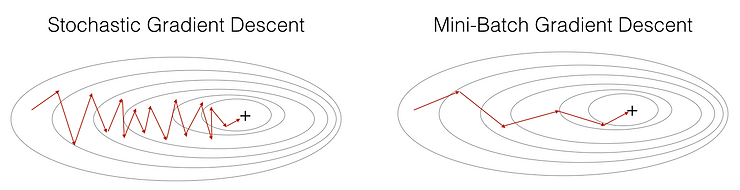
</div>


Contudo, o MB-SGD também apresenta desvantagens. A escolha do tamanho do lote é tida como um hiperparâmetro e pode influenciar diretamente o desempenho do treinamento, exigindo certo cuidado. Além disso, assim como o SGD, ele ainda depende de uma taxa de aprendizado fixa, o que significa que não adapta automaticamente o passo de atualização para cada parâmetro. Por último, mesmo sendo mais estável, ele ainda pode enfrentar dificuldades em superfícies de erro complexas, podendo ficar preso em mínimos locais ou pontos de sela.

* Momentum- algoritmo que melhora a descida do gradiente convencional ao acrescentar um termo de velocidade que acumula os gradientes das etapas anteriores, permitindo que o otimizador avance mais rapidamente em direções consistentes e reduza oscilações em direções de alta curvatura. A regra de atualização considerando o momento pode ser escrita como: $$ v_t = \gamma v_{t-1} + \eta \, \nabla J(\theta_t) $$ $$ \theta_{t+1} = \theta_t - v_t $$

onde:
- $v_t$ é a velocidade no passo $t$,
- $\gamma$ é o coeficiente de momentum,
- $\eta$ é a taxa de aprendizado,
- $\nabla J(\theta_t)$ é o gradiente da função de custo no passo $t$.

Essa formulação introduz uma "memória" no processo de otimização, o que permite suavizar oscilações e acelerar a convergência. No entanto, a taxa de aprendizado ainda permanece fixa, se ela for muito alta, o treinamento pode divergir, mas se for muito baixa, a convergência se torna muito lenta. E o coeficiente de momentum também depende do ajuste manual. Portanto, do mesmo modo, momentum em excesso pode causar oscilações, enquanto momentum insuficiente faz o método se aproximar bastante da descida do gradiente simples (GD). Abaixo segue uma representação gráfica da diferença obtida com a implementação do momento no SGD [3]:

<div style="text-align: center;">
    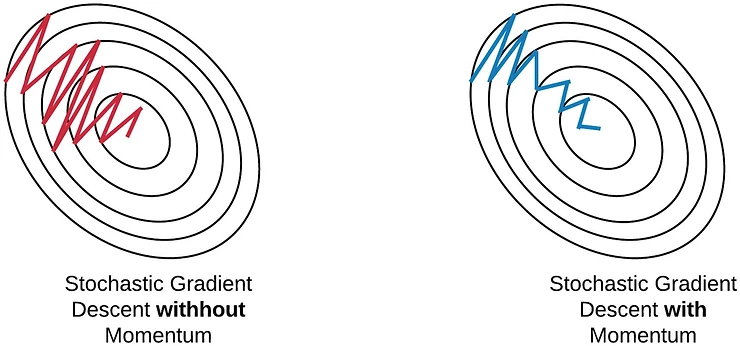
</div>


Diante do exposto, é possível perceber que as variantes da descida do gradiente compartilhadas até aqui apresentam alguns desafios em comum, dado que elas aplicam a mesma taxa de aprendizado a todos os parâmetros, sem adaptação individual. Além de dificuldades relativas a problemas mais complexos e de convergência. Diante dessas limitações, surgem os otimizadores mais avançados, que procuram lidar com esses problemas de maneiras diferentes e que serão exploradas mais à frente.


### 3. Implementação em Python 

Nesse momento, exploraremos os conceitos discutidos até aqui e sua aplicabilidade computacional para otimização de redes neurais a partir de dois exemplos. Para isso, vamos seguir com a implementação do algoritmo de otimização em `Python`, para explicitar a lógica interna do método. As redes implementadas utilizarão a biblioteca do `Pytorch` para construir a arquitetura da rede. Contudo, a etapa de otimização será implementada manualmente, sem o uso dos otimizadores prontos da biblioteca, permitindo controle explícito sobre a atualização dos parâmetros. O processo de treinamento pode ser organizado nas seguintes etapas [12]:

1. Definição dos dados de entrada
2. Definição dos hiperparâmetros
3. Definição do treinamento da rede:
* Funções de ativação
* Funções de perda
* Forward pass
* Backpropagation
* Implementação do algoritmo de otimização
* Atualização dos parâmetros

4. Execução do treinamento e plotagem dos resultados



#### 3.1 Rede 01 
Nessa primeira implementação exploraremos uma rede bem simples em que a função de ativação é linear e avaliaremos o seu comportamento com a descida do gradiente com e sem momentum, através da sua curva de aprendizado.

Epoch 10: loss = 0.4522
Epoch 20: loss = 0.1937
Epoch 30: loss = 0.1764
Epoch 40: loss = 0.1660
Epoch 50: loss = 0.1563
Epoch 60: loss = 0.1472
Epoch 70: loss = 0.1387
Epoch 80: loss = 0.1306
Epoch 90: loss = 0.1230
Epoch 100: loss = 0.1158
Epoch 10: loss = 1.6725
Epoch 20: loss = 0.1367
Epoch 30: loss = 0.3408
Epoch 40: loss = 0.0844
Epoch 50: loss = 0.0106
Epoch 60: loss = 0.0157
Epoch 70: loss = 0.0037
Epoch 80: loss = 0.0004
Epoch 90: loss = 0.0006
Epoch 100: loss = 0.0001


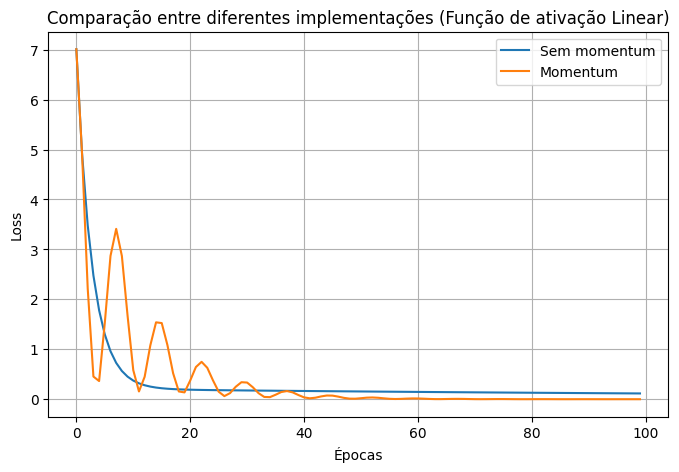

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Dados simples 
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])

# 2. Função de perda
loss_fn = nn.MSELoss()

# 3. Hiperparâmetros 
learning_rate = 0.01
momentum = 0.9
epochs = 100

def train_model(use_momentum=False, corrected=True):
    # Modelo simples 
    model = nn.Linear(1, 1)

    # Velocidades
    velocity_w = 0.0
    velocity_b = 0.0

    loss_history = []

    for epoch in range(epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss_history.append(loss.item())

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            w_grad = model.weight.grad.item()
            b_grad = model.bias.grad.item()

            if use_momentum:
                if corrected:
                    velocity_w = momentum * velocity_w + w_grad
                    velocity_b = momentum * velocity_b + b_grad

                    model.weight -= learning_rate * velocity_w
                    model.bias -= learning_rate * velocity_b
                
            else:
                # Sem momentum 
                model.weight -= learning_rate * w_grad
                model.bias -= learning_rate * b_grad

            model.weight.grad.zero_()
            model.bias.grad.zero_()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

    return model, loss_history

# =========================
# TREINOS COM MESMA SEED
# =========================

# Sem momentum
torch.manual_seed(42)
model_no_momentum, loss_no_momentum = train_model(use_momentum=False)

# Momentum 
torch.manual_seed(42)
model_correct_momentum, loss_correct_momentum = train_model(use_momentum=True, corrected=True)

# =========================
# GRÁFICO
# =========================

plt.figure(figsize=(8, 5))

plt.plot(loss_no_momentum, label="Sem momentum")
plt.plot(loss_correct_momentum, label="Momentum")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Comparação entre diferentes implementações (Função de ativação Linear)")
plt.legend()
plt.grid(True)
plt.show()


Dada a representação gráfica acima, conseguimos perceber que para uma função bem comportada como a linear o incremento do momento não auxília para além de acelerar a descida do gradiente no início, pois assume um comportamento bastante ruidoso por um certo período depois para então convergir para um valor menor e constante. Esse comportamento está associado ao acúmulo de inércia introduzido pelo método, no qual a atualização dos parâmetros continua sendo influenciada por gradientes anteriores, fazendo com que o modelo ultrapasse o ponto de mínimo e oscile em torno dele antes de estabilizar. Isso se dá pois o processo de otimização é bastante sensível aos hiperparâmetros, em especial à taxa de aprendizado e ao coeficiente de momentum, mas também porque a superfície de erro associada a esse problema é simples e bem comportada, reduzindo a necessidade de mecanismos adicionais de aceleração como o momentum.

#### 3.2 Rede 02
Analogamente, nessa segunda implementação exploraremos uma rede um pouco mais complexa, em que a função de ativação é não-linear e avaliaremos o seu comportamento com a descida do gradiente com e sem momentum, também segundo sua curva de aprendizado.

Epoch 10: loss = 6.4600
Epoch 20: loss = 5.4558
Epoch 30: loss = 4.7900
Epoch 40: loss = 4.3217
Epoch 50: loss = 3.9786
Epoch 60: loss = 3.7204
Epoch 70: loss = 3.5222
Epoch 80: loss = 3.3682
Epoch 90: loss = 3.2470
Epoch 100: loss = 3.1509
Epoch 10: loss = 4.1349
Epoch 20: loss = 3.0035
Epoch 30: loss = 3.0885
Epoch 40: loss = 2.8876
Epoch 50: loss = 2.7166
Epoch 60: loss = 2.6206
Epoch 70: loss = 2.5203
Epoch 80: loss = 2.4376
Epoch 90: loss = 2.3722
Epoch 100: loss = 2.3179


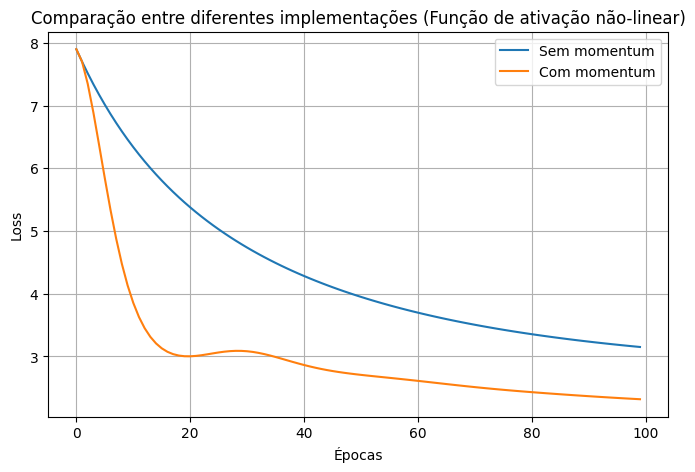

In [2]:
# 1. Dados mais complexos (não linear + ruído)
torch.manual_seed(42)
X = torch.linspace(-2, 2, 20).unsqueeze(1)
y = X**3 + 0.5 * torch.randn_like(X)

# 2. Função de perda
loss_fn = nn.MSELoss()

# 3. Hiperparâmetros ajustados
learning_rate = 0.003
momentum = 0.9
epochs = 100

def train_model(use_momentum=False):
    # 4. Mesmo modelo para ambos os casos
    model = nn.Sequential(
        nn.Linear(1, 10),
        nn.Tanh(),
        nn.Linear(10, 1)
    )

    # 5. Inicialização controlada (igual para comparação justa)
    for param in model.parameters():
        torch.nn.init.constant_(param, 0.5)

    # 6. Velocidades (mesmo formato dos parâmetros)
    velocities = [torch.zeros_like(p) for p in model.parameters()]

    loss_history = []

    for epoch in range(epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss_history.append(loss.item())

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            for i, param in enumerate(model.parameters()):
                grad = param.grad

                if use_momentum:
                    # v_t = beta * v_{t-1} + gradiente
                    velocities[i] = momentum * velocities[i] + grad
                    # θ = θ - η * v_t
                    param -= learning_rate * velocities[i]
                else:
                    # θ ← θ − η ∇J(θ)
                    param -= learning_rate * grad

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

    return model, loss_history

# 7. Treino sem momentum 
torch.manual_seed(42)
model_no_momentum, loss_no_momentum = train_model(use_momentum=False)

# 8. Treino com momentum 
torch.manual_seed(42)
model_with_momentum, loss_with_momentum = train_model(use_momentum=True)

# 9. Gráfico de comparação
plt.figure(figsize=(8, 5))
plt.plot(loss_no_momentum, label="Sem momentum")
plt.plot(loss_with_momentum, label="Com momentum")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Comparação entre diferentes implementações (Função de ativação não-linear)")
plt.legend()
plt.grid(True)
plt.show()


Nesse caso, observa-se uma redução mais rápida da função de perda e uma convergência mais eficiente ao longo das épocas. Diferentemente do caso linear, o comportamento apresenta menor impacto relativo das oscilações iniciais, uma vez que o acúmulo de inércia contribui para atravessar regiões mais planas da superfície de erro e manter uma direção de descida mais consistente. Isso permite que o modelo evite estagnação em regiões de gradiente reduzido e avance de forma mais eficiente em direção ao mínimo. Dessa forma, é possível concluir que o processo de otimização está diretamente relacionado à geometria da função de perda, que nesse caso é mais complexa e apresenta maior variação nos gradientes, tornando o uso de momentum mais relevante e eficaz.

Por fim, a descida do gradiente constitui um método de otimização fundamental no treinamento de redes neurais, sendo responsável pela atualização iterativa dos parâmetros do modelo. A introdução do termo de momentum nesse processo incorpora informação de gradientes anteriores. Isso permite acelerar a convergência e suavizar oscilações, especialmente em superfícies de erro mais complexas. No entanto, seu benefício depende da escolha adequada de hiperparâmetros e da geometria do problema considerado. Logo, a necessidade de existir otimizadores mas avançados que possam suprir certas demandas ainda não resolvidas pelos algoritmos vistos até aqui é concreta.

### 4. Otimizadores Avançados

O contexto apresentado até aqui pôde revelar a importância dos otimizadores e sua contribuição para o processo de previsão das redes neurais. No entanto, como já relatado, ainda existem algumas limitações a serem superadas em especial as relativas à taxa de aprendizado fixa e convergências mais suáveis, estáveis e rápidas.
Nesse sentido, abaixo serão apresentados alguns novos algoritmos que se propõem a solucionar essas adversidades.

* AdaGrad - algoritmo que introduz a ideia de taxas de aprendizado adaptativas por parâmetro, sendo um dos primeiros métodos a incorporar essa estratégia na otimização de modelos. Projetado para adaptar a taxa de aprendizado de cada parâmetro, acumulando o histórico dos quadrados dos gradientes. Isso permite passos maiores em direções pouco atualizadas e menores em direções frequentemente atualizadas. A regra de atualização pode ser escrita como: $$ G_{t,ii} = G_{t-1,ii} + \left( \nabla J(\theta_t)_i \right)^2 $$ $$ \theta_{t+1,i} = \theta_{t,i} - \frac{\alpha}{\sqrt{G_{t,ii} + \epsilon}} \cdot \nabla J(\theta_t)_i $$

onde:
- $G_{t,ii}$ é o acumulador dos quadrados dos gradientes para o parâmetro $i$,
- $\alpha$ é a taxa de aprendizado base,
- $\epsilon$ é um pequeno valor para evitar divisão por zero,
- $\nabla J(\theta_t)_i$ é o gradiente em relação ao parâmetro $i$.

Essa formulação implica que a taxa de aprendizado efetiva diminui ao longo do tempo para parâmetros que acumulam grandes valores de gradiente.

Além disso, a característica observado no AdaGrad de que os parâmetros mais atualizados recebem passos menores de maneira progressiva enquanto aqueles que são menos atualizados recebem passos relativamente maiores torna esse algoritmo bastante eficaz em problemas com dados esparsos, como em aplicações de processamento de linguagem natural, onde certas características aparecem com baixa frequência, mas carregam informação relevante.

Embora o AdaGrad possua todas essas qualidades, o algoritmo apresenta uma limitação importante: o termo acumulado  $G_{t,ii}$ cresce monotonamente ao longo do treinamento o que faz com que o denominador da atualização aumente continuamente. Isso implica em uma tendência a reduzir excessivamente a taxa de aprendizado ao longo do tempo, levando à estagnação do processo de treinamento. Outro ponto é, que o método requer o armazenamento de informações adicionais para cada parâmetro, o que pode aumentar o custo computacional. Esses apontamentos, portanto, motivaram o desenvolvimento de métodos mais elaborados, os quais buscam contornar essas limitações mantendo a ideia de adaptação dos passos de atualização.

* RMSProp - um algoritmo que surgiu como uma solução para a principal limitação do AdaGrad, relacionada ao decaimento excessivo da taxa de aprendizado ao longo do treinamento. Ele utiliza uma média móvel exponencial dos quadrados dos gradientes, substituindo assim o acúmulo desses gradientes ao permitir que o algoritmo “esqueça” gradientes antigos e mantenha a taxa de aprendizado adaptativa ao longo do tempo. O uso da média móvel impede que o denominador cresça indefinidamente, mantendo valores de atualização mais equilibrados ao longo do treinamento. A regra de atualização pode ser escrita como: $$ E[g^2]_t = \gamma E[g^2]_{t-1} + (1 - \gamma)\left(\nabla J(\theta_t)\right)^2 $$ $$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \cdot \nabla J(\theta_t) $$

onde:
- $E[g^2]_t$ é a média móvel dos quadrados dos gradientes,
- $\gamma$ é o fator de decaimento (tipicamente próximo de 1),
- $\eta$ é a taxa de aprendizado,
- $\epsilon$ é um pequeno valor para evitar divisão por zero,
- $\nabla J(\theta_t)$ é o gradiente no passo $t$.

Uma das principais vantagens do RMSProp é evitar a redução constante da taxa de aprendizado, característica que pode comprometer o desempenho do AdaGrad em treinamentos prolongados. Além disso, o método é bastante eficaz em cenários com funções de custo cujo comportamento é afetado conforme a mudança dos parâmetros da rede neural, provocando uma mundança no erro que se busca mnimizar, pois este se transforma ao longo do tempo. Como ocorre em redes neurais profundas do tipo recorrentes (RNNs), em que existe uma alta correspondência entre suas camadas, introduzindo uma espécie de dinâmica ao problema de otimização. Nesse contexto, a capacidade de adaptação contínua do RMSProp contribui para uma convergência mais estável e eficiente. Por outro lado, o RMSProp ainda exige a definição manual de hiperparâmetros, como a taxa de aprendizado e o fator de decaimento, o que pode influenciar significativamente seu desempenho. Para fins de curiosidade, é interessante explicitar que o RMSProp possui uma estrutura similar a um outro algoritmo chamado de AdaDelta, o qual não abordaremos mais afundo neste notebook, porém pode-se consultar a literatura presente nas referências [6] para mais informações.

* Adam - projetado para combinar as principais ideias dos métodos de otimização baseados em momentum e do RMSProp, incorpora tanto a média móvel dos gradientes quanto a média móvel dos quadrados dos gradientes, além de um mecanismo de correção de viés. Dessa forma, pode ser entendido como uma extensão que reúne os benefícios de diferentes abordagens adaptativas em um único algoritmo. Capaz de melhorar a estimativa de termos ainda nas etapas iniciais do treinamento. As estimativas são atualizadas ao longo do treinamento e utilizadas para ajustar dinamicamente o tamanho dos passos dados em cada direção do espaço de parâmetros. Um destaque desse algoritmo é a aplicação de uma correção de viés nessas estimativas, especialmente relevante nas primeiras iterações, quando os valores ainda estão próximos de zero devido à inicialização. Formalmente, o otimizador Adam realiza as seguintes atualizações:: $$ m_t = \beta_1 m_{t-1} + (1 - \beta_1)\nabla J(\theta_t) $$ $$ v_t = \beta_2 v_{t-1} + (1 - \beta_2)\left(\nabla J(\theta_t)\right)^2 $$

Em seguida, são calculadas as versões corrigidas para viés:

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}
\qquad
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

Por fim, a atualização dos parâmetros é dada por:

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t
$$

onde:
- $\beta_1$ e $\beta_2$ controlam o decaimento das médias móveis,
- $\eta$ é a taxa de aprendizado,
- $\epsilon$ é um termo de estabilidade numérica.

Com isso, o Adam apresenta convergência rápida, boa estabilidade numérica e adaptação automática da taxa de aprendizado para cada parâmetro, sendo amplamente utilizado em uma grande variedade de aplicações em `deep learning`. Atende a maior parte dos problemas aqui expostos, como de dados esparsos, ruidosos ou cenários dinâmicos para as funções de perda. Apesar dessas vantagens, o método também apresenta limitações, ao passo que pode ter maior custo computacional em relação a métodos mais simples e ainda requerer a escolha de hiperparâmetros, como a taxa de aprendizado inicial. Além disso, em alguns contextos, especialmente com conjuntos de dados menores ou quando se busca maior capacidade de generalização, métodos mais simples como o SGD com momentum podem apresentar desempenho superior, por tenderem a encontrar mínimos mais “planos”, associados a soluções mais eficientes.

Abaixo segue uma representação esquemática de diferentes tipos de otimizadores e algumas de suas características principais [6]:

<div style="text-align: center;">
    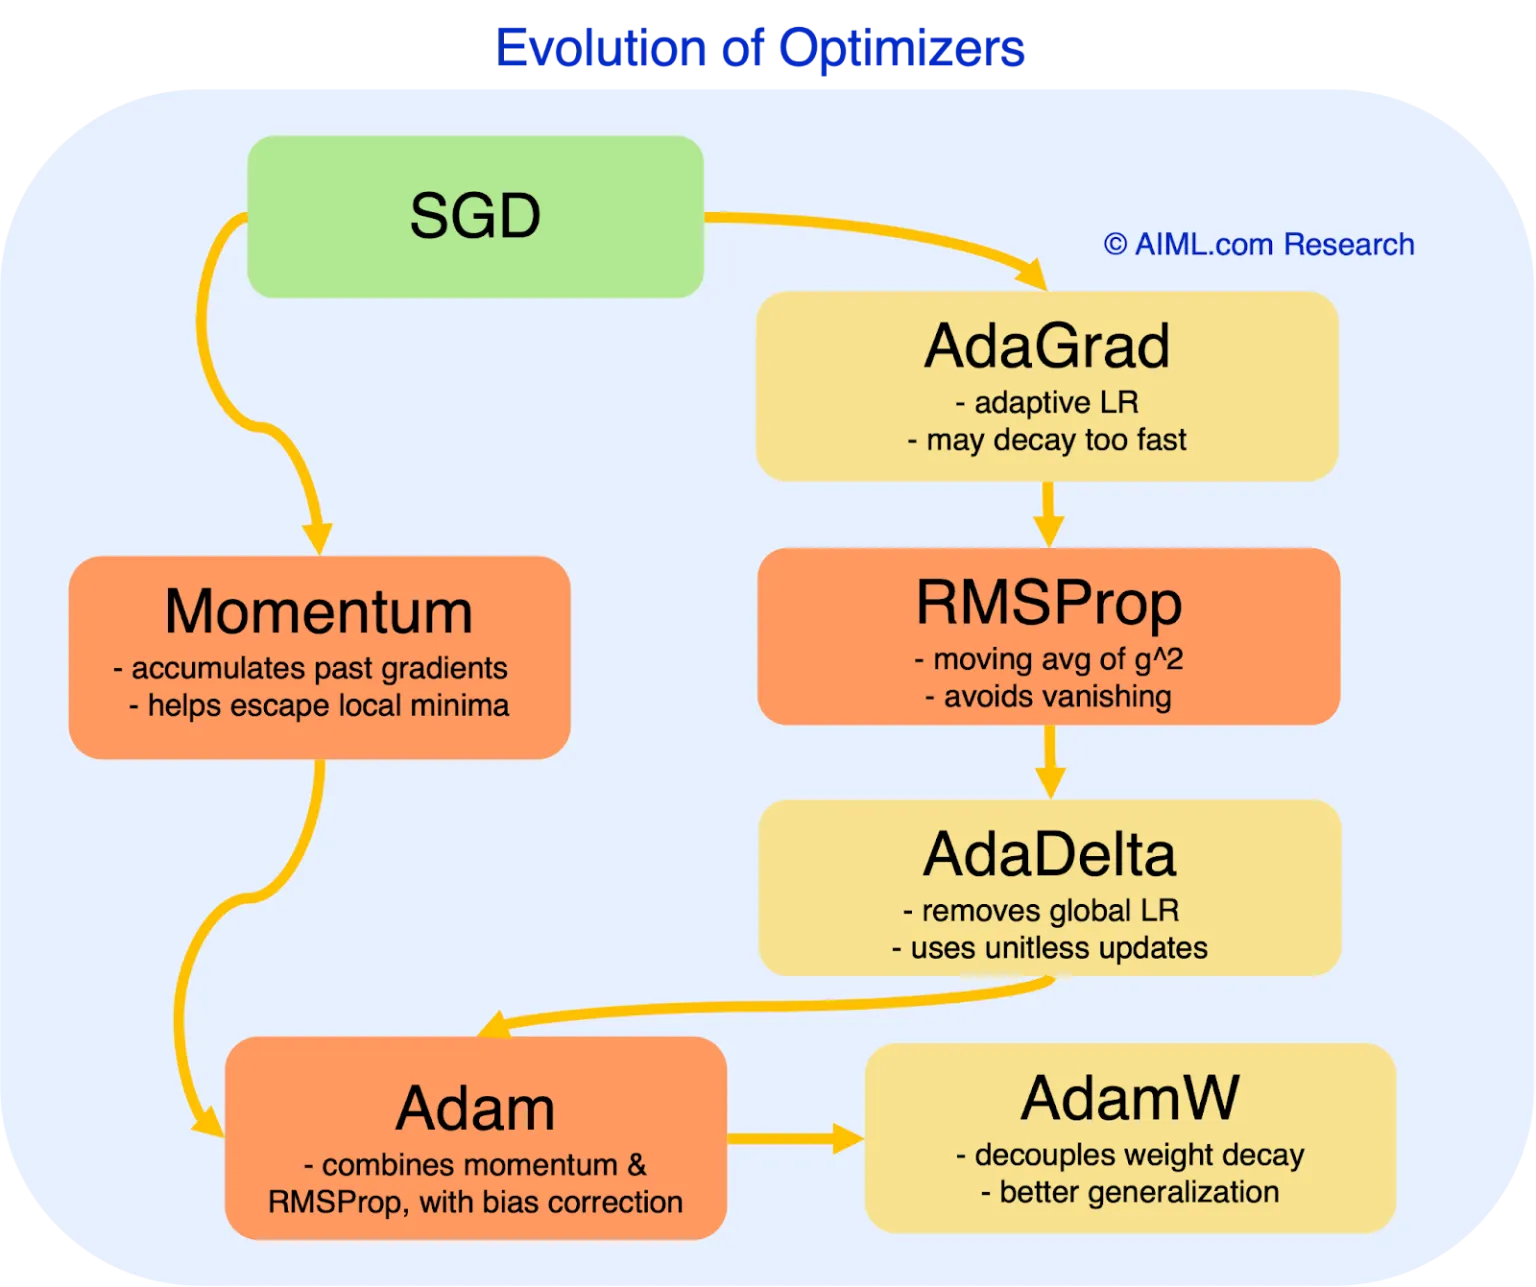
</div>

*Observação*: Não abordaremos em maiores detalhes o otimizador AdamW. No entanto, é interessante evidenciar que ele se trata de uma versão melhorada do otimizador Adam. Ele separa o `weight decay` do processo de atualização dos parâmetros. O `weight decay` é uma técnica que reduz gradualmente o valor dos pesos do modelo ao longo do treinamento, evitando que eles cresçam demais e fazendo com que o modelo não se ajuste excessivamente aos dados de treino (overfitting). Enquanto no Adam original esse efeito está acoplado ao cálculo do gradiente, no AdamW ele é aplicado de forma independente, tornando esse controle mais direto e consistente e, em muitos casos, melhorando a capacidade de generalização. Essa modificação resulta em uma regularização mais estável e previsível, especialmente em modelos de grande escala, como aqueles baseados em arquiteturas do tipo `Transformer`, incluindo o `BERT`.

### 5. Comparação e escolha do otimizador






A escolha do otimizador varia conforme o problema que se deseja resolver, a arquitetura do modelo e a natureza dos dados envolvidos. Em modelos mais complexos, alguns métodos tendem a oferecer melhor desempenho, enquanto em situações com dados esparsos, ruído elevado,  outros se mostram mais vantajosos. Para sintetizar essas diferenças, a tabela a seguir reúne uma visão geral dos otimizadores estudados:



| Otimizador | Formulação conceitual | Vantagens | Limitações | Comportamento típico | Situações típicas de uso |
| --- | --- | --- | --- | --- | --- |
| Gradient Descent (GD) | Calcula o gradiente utilizando o conjunto de dados completo a cada iteração. | Apresenta trajetória estável e interpretação conceitual simples. | Pode apresentar convergência lenta e maior custo computacional. | Atualizações suaves, porém gradativas. | Problemas de menor escala e contextos didáticos em que a estabilidade do processo é prioritária. |
| Stochastic Gradient Descent (SGD) | Calcula o gradiente com base em uma única amostra ou em pequenas amostras por atualização. | Permite atualizações mais rápidas e pode escapar de alguns mínimos locais. | Introduz maior variabilidade nas atualizações e pode tornar o processo instável. | Trajetória oscilatória e menos regular. | Treinamento de redes neurais em geral, especialmente em cenários que exigem escalabilidade e eficiência computacional. |
| Momentum | Incorpora uma componente de inércia ao acumular informação de gradientes anteriores. | Reduz oscilações e tende a acelerar a convergência. | Pode ultrapassar regiões ótimas se os hiperparâmetros não forem bem ajustados. | Movimento mais suave e direcionado. | Situações em que o SGD puro apresenta oscilações excessivas ou convergência lenta. |
| AdaGrad | Adapta a taxa de aprendizado com base no histórico acumulado dos gradientes. | É particularmente eficiente em problemas com parâmetros esparsos. | A taxa de aprendizado pode decair demasiadamente ao longo do tempo. | Inicialmente rápido, mas com desaceleração acentuada. | Problemas com alta esparsidade, como processamento de linguagem natural e sistemas de recomendação. |
| RMSProp | Emprega uma média móvel dos gradientes quadráticos para corrigir limitações do AdaGrad. | Tende a oferecer comportamento mais estável e eficiente. | Requer ajuste cuidadoso de hiperparâmetros. | Convergência mais equilibrada. | Redes recorrentes, séries temporais e cenários com gradientes instáveis. |
| Adam | Combina ideias de Momentum e RMSProp, incorporando estimativas adaptativas do primeiro e segundo momentos. | Convergência rápida e bom desempenho em muitos contextos práticos. | Pode não apresentar a melhor generalização em alguns problemas específicos. | Atualizações rápidas, suaves e adaptativas. | Uma escolha geral frequentemente adotada em `deep learning`, especialmente em modelos mais complexos. |


Assim, temos sumarizada a ideia principal correspondente a cada tipo de otimizador e suas características, evidenciando suas particularidades, vantagens e limitações. A comparação realizada permite identificar de forma mais clara as circunstâncias em que cada método tende a ser mais adequado, considerando eficiência computacional, estabilidade de convergência e comportamento durante o treinamento. 

### Conclusão

Em síntese, o estudo realizado permitiu compreender a importância dos otimizadores no processo de treinamento de modelos preditivos, em especial em `deep learning`, evidenciando seu papel central na busca por maior eficiência, estabilidade e qualidade na convergência. Ao longo da análise, observou-se que não existe um único otimizador superior, mas sim métodos mais ou menos adequados conforme a natureza do problema, o volume de dados e o comportamento esperado durante o ajuste dos parâmetros. Dessa forma, abordagens como Gradient Descent, SGD, Momentum, AdaGrad, RMSProp e Adam apresentam características distintas que influenciam diretamente o desempenho do modelo. Assim, a escolha do otimizador deve ser feita de forma criteriosa, considerando as particularidades da aplicação e os objetivos da modelagem. Portanto, conclui-se que a compreensão dessas técnicas é fundamental para a construção de soluções mais eficientes e estruturadas no contexto da inteligência artificial.

### Referências
1. CAETANO, Marco Antonio Leonel. Otimização. In: CAETANO, Marco Antonio Leonel. Éden dos algoritmos em Python. São Paulo: Editora Blucher, 2024. Disponível em: https://integrada.minhabiblioteca.com.br/reader/books/9788521220480
2. Data Science e Machine Learning (Parte 21): Desvendando Redes Neurais, Algoritmos de Otimização Desmistificados https://www.mql5.com/pt/articles/14435
3. Deep Learning: Comparing Various Optimization Techniques https://milav.in/blog/deep-learning-optimization-comparison/
4. Conceitos de Machine Learning https://developers.google.com/machine-learning/crash-course/linear-regression/loss?hl=pt-br
5. Gradiente https://pt.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/partial-derivative-and-gradient-articles/a/the-gradient
6. Comparison of Optimization Algorithms: SGD, Adagrad, Adam and more https://aiml.com/comparing-optimization-algorithms-in-deep-learning-sgd-adam-and-more/
7. Gradiente descendente https://apxml.com/courses/deep-learning-regularization-optimization/chapter-5-foundational-optimizers/revisiting-gradient-descent
8. Função de perda https://www.ibm.com/br-pt/think/topics/loss-function
9. Curva de aprendizado https://huggingface.co/learn/llm-course/en/chapter3/5
10. Otimização convexa https://pt.dataconomy.com/2025/04/04/otimizacao-convexa
11. Explicação do Adagrad Optimizer: Como funciona, implementação e comparações https://www.datacamp.com/pt/tutorial/adagrad-optimizer-explained
12. Consultas, ajustes textuais e código https://chatgpt.com/
13. O que é o gradiente descendente estocástico? https://www.ibm.com/br-pt/think/topics/stochastic-gradient-descent
14. Consultas, ajustes textuais e tabela https://www.perplexity.ai/